# SVM

#### Imports

In [27]:
%load_ext autoreload
%autoreload 2

import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd

from src.svm_experiment import SVMExperiment
from src.utils import evaluate_model, save_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Experimento 1: Conjunto com todas as Features

In [28]:
import pandas as pd
caminho = '../'

X_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_test.csv')
X_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/X_train.csv')
y_test_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp1 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### SVM - Default

In [29]:
from sklearn.svm import SVC

svm_exp1 = SVC(kernel='rbf', probability=True, random_state=14)
svm_exp1.fit(X_train_exp1, y_train_exp1)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== Métricas svm_def_exp1  ===
    Acurácia: 0.7703
    Precisão: 0.7509
    Recall:   0.7046
    F1-Score: 0.7174
    MCC:      0.4532
    AUC:      0.8571


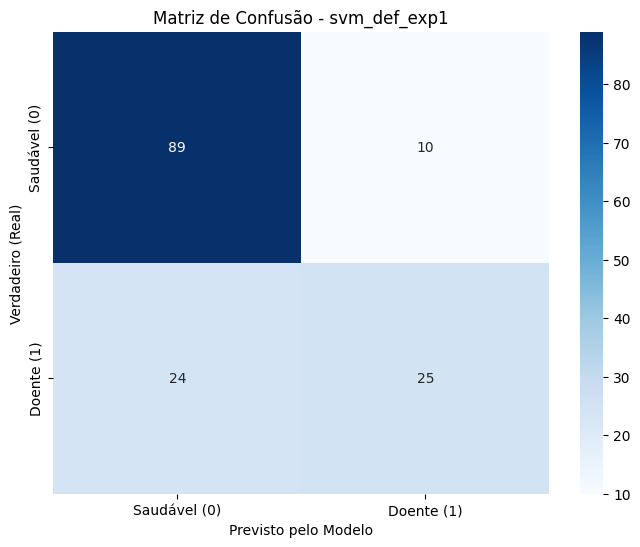

In [30]:
# Avaliar modelo
y_pred_def_exp1 = svm_exp1.predict(X_test_exp1)
y_prob_def_exp1 = svm_exp1.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1')
save_results(y_pred_def_exp1, y_prob_def_exp1, 'svm_def_exp1', caminho)

### SVM - Melhorado

In [31]:
# Criar o experimento
experimento_1 = SVMExperiment(X_train_exp1, y_train_exp1, 'svm_otz_exp1', caminho)
experimento_1.tune_and_fit(n_trials=50)
best_svm = experimento_1.best_model

[I 2026-08-18 19:24:24,601] A new study created in memory with name: no-name-03925cc0-80d7-4464-9583-ecfcebdc2f9e


Iniciando otimização do cenário svm_otz_exp1.


Best trial: 0. Best value: 0.714797:   2%|▏         | 1/50 [00:06<04:59,  6.12s/it]

[I 2026-08-18 19:24:30,719] Trial 0 finished with value: 0.7147969887695914 and parameters: {'kernel': 'poly', 'C': 0.11584246177035416, 'gamma': 'auto', 'tol': 1.3259987302470086e-05, 'shrinking': False, 'degree': 4, 'coef0': 0.3881623442701134}. Best is trial 0 with value: 0.7147969887695914.


Best trial: 0. Best value: 0.714797:   4%|▍         | 2/50 [00:12<05:00,  6.27s/it]

[I 2026-08-18 19:24:37,096] Trial 1 finished with value: 0.6695668271010736 and parameters: {'kernel': 'sigmoid', 'C': 15.597602344631447, 'gamma': 'scale', 'tol': 0.004602640715413017, 'shrinking': True, 'coef0': 0.6288009864836602}. Best is trial 0 with value: 0.7147969887695914.


Best trial: 0. Best value: 0.714797:   6%|▌         | 3/50 [00:19<05:03,  6.45s/it]

[I 2026-08-18 19:24:43,752] Trial 2 finished with value: 0.6741947426878934 and parameters: {'kernel': 'sigmoid', 'C': 0.11118405207165905, 'gamma': 'auto', 'tol': 0.05011855712688662, 'shrinking': True, 'coef0': 0.09105770178774542}. Best is trial 0 with value: 0.7147969887695914.


Best trial: 4. Best value: 0.751018:  10%|█         | 5/50 [00:26<03:14,  4.32s/it]

[I 2026-08-18 19:24:50,822] Trial 3 finished with value: 0.7284339133654202 and parameters: {'kernel': 'poly', 'C': 8.640007385755545, 'gamma': 'auto', 'tol': 0.009528729887491214, 'shrinking': False, 'degree': 2, 'coef0': 0.12991652693753364}. Best is trial 3 with value: 0.7284339133654202.
[I 2026-08-18 19:24:50,942] Trial 4 finished with value: 0.7510181414291003 and parameters: {'kernel': 'poly', 'C': 1.3253834672286118, 'gamma': 'scale', 'tol': 0.008703054040278895, 'shrinking': False, 'degree': 3, 'coef0': 0.8319341345253412}. Best is trial 4 with value: 0.7510181414291003.
[I 2026-08-18 19:24:50,984] Trial 5 finished with value: 0.682956929532272 and parameters: {'kernel': 'sigmoid', 'C': 71.98948038262084, 'gamma': 'auto', 'tol': 0.015362773872525805, 'shrinking': False, 'coef0': 0.8585246282897455}. Best is trial 4 with value: 0.7510181414291003.


Best trial: 8. Best value: 0.751203:  18%|█▊        | 9/50 [00:26<00:52,  1.28s/it]

[I 2026-08-18 19:24:51,049] Trial 6 finished with value: 0.7057879797605825 and parameters: {'kernel': 'poly', 'C': 14.974574853200728, 'gamma': 'scale', 'tol': 0.003320746811947358, 'shrinking': True, 'degree': 2, 'coef0': 0.5184351774778586}. Best is trial 4 with value: 0.7510181414291003.
[I 2026-08-18 19:24:51,106] Trial 7 finished with value: 0.7102924842650871 and parameters: {'kernel': 'poly', 'C': 0.18333069815963593, 'gamma': 'auto', 'tol': 0.00011266318046531456, 'shrinking': True, 'degree': 4, 'coef0': 0.25172690217418847}. Best is trial 4 with value: 0.7510181414291003.
[I 2026-08-18 19:24:51,185] Trial 8 finished with value: 0.751203258052573 and parameters: {'kernel': 'rbf', 'C': 16.031558936479584, 'gamma': 'auto', 'tol': 0.0010679830988763108, 'shrinking': False}. Best is trial 8 with value: 0.751203258052573.


Best trial: 10. Best value: 0.755646:  22%|██▏       | 11/50 [00:26<00:32,  1.21it/s]

[I 2026-08-18 19:24:51,255] Trial 9 finished with value: 0.7420708379612488 and parameters: {'kernel': 'poly', 'C': 14.281213056715865, 'gamma': 'auto', 'tol': 0.07857055867352848, 'shrinking': False, 'degree': 4, 'coef0': 0.4145806665323629}. Best is trial 8 with value: 0.751203258052573.
[I 2026-08-18 19:24:51,348] Trial 10 finished with value: 0.75564605701592 and parameters: {'kernel': 'rbf', 'C': 92.08423259109188, 'gamma': 'scale', 'tol': 0.000543538706594576, 'shrinking': False}. Best is trial 10 with value: 0.75564605701592.
[I 2026-08-18 19:24:51,436] Trial 11 finished with value: 0.75564605701592 and parameters: {'kernel': 'rbf', 'C': 77.4833831097905, 'gamma': 'scale', 'tol': 0.0003872687961197715, 'shrinking': False}. Best is trial 10 with value: 0.75564605701592.


Best trial: 14. Best value: 0.787424:  30%|███       | 15/50 [00:27<00:14,  2.44it/s]

[I 2026-08-18 19:24:51,530] Trial 12 finished with value: 0.75564605701592 and parameters: {'kernel': 'rbf', 'C': 71.59753647163011, 'gamma': 'scale', 'tol': 0.0002054218827343401, 'shrinking': False}. Best is trial 10 with value: 0.75564605701592.
[I 2026-08-18 19:24:51,622] Trial 13 finished with value: 0.75564605701592 and parameters: {'kernel': 'rbf', 'C': 83.77084425887638, 'gamma': 'scale', 'tol': 0.00019030270557746063, 'shrinking': False}. Best is trial 10 with value: 0.75564605701592.
[I 2026-08-18 19:24:51,695] Trial 14 finished with value: 0.7874244107120819 and parameters: {'kernel': 'rbf', 'C': 2.0548928629297394, 'gamma': 'scale', 'tol': 0.0005231041678179565, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  34%|███▍      | 17/50 [00:27<00:09,  3.32it/s]

[I 2026-08-18 19:24:51,771] Trial 15 finished with value: 0.7601505615204246 and parameters: {'kernel': 'rbf', 'C': 1.1664449305211135, 'gamma': 'scale', 'tol': 4.078522654599182e-05, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:51,844] Trial 16 finished with value: 0.7647784771072442 and parameters: {'kernel': 'rbf', 'C': 0.8796157914246068, 'gamma': 'scale', 'tol': 3.2404006185964416e-05, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:51,919] Trial 17 finished with value: 0.7557694680982352 and parameters: {'kernel': 'rbf', 'C': 0.4425523783736477, 'gamma': 'scale', 'tol': 1.383150791007376e-05, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  40%|████      | 20/50 [00:27<00:06,  4.30it/s]

[I 2026-08-18 19:24:52,006] Trial 18 finished with value: 0.7602739726027398 and parameters: {'kernel': 'rbf', 'C': 3.567868767070206, 'gamma': 'scale', 'tol': 4.064515201836787e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,096] Trial 19 finished with value: 0.7557077625570776 and parameters: {'kernel': 'rbf', 'C': 0.7673884865750723, 'gamma': 'scale', 'tol': 0.0013450304685149706, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,193] Trial 20 finished with value: 0.7602122670615822 and parameters: {'kernel': 'rbf', 'C': 3.8655406201767653, 'gamma': 'scale', 'tol': 4.2014344384243536e-05, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  46%|████▌     | 23/50 [00:27<00:04,  6.36it/s]

[I 2026-08-18 19:24:52,274] Trial 21 finished with value: 0.773849191657411 and parameters: {'kernel': 'rbf', 'C': 2.801922585099078, 'gamma': 'scale', 'tol': 3.845264025955946e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,363] Trial 22 finished with value: 0.7874244107120819 and parameters: {'kernel': 'rbf', 'C': 1.9212176453164969, 'gamma': 'scale', 'tol': 8.075219053754421e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,443] Trial 23 finished with value: 0.778415401703073 and parameters: {'kernel': 'rbf', 'C': 2.2087439518010266, 'gamma': 'scale', 'tol': 9.080356207676625e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  54%|█████▍    | 27/50 [00:28<00:02,  8.37it/s]

[I 2026-08-18 19:24:52,532] Trial 24 finished with value: 0.7874244107120819 and parameters: {'kernel': 'rbf', 'C': 2.0503500958572136, 'gamma': 'scale', 'tol': 0.00010499763509346954, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,629] Trial 25 finished with value: 0.6830186350734295 and parameters: {'kernel': 'sigmoid', 'C': 7.376796910681267, 'gamma': 'scale', 'tol': 0.000352458437948171, 'shrinking': True, 'coef0': 0.9677358451037607}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,705] Trial 26 finished with value: 0.7557694680982352 and parameters: {'kernel': 'rbf', 'C': 0.4000254763529859, 'gamma': 'scale', 'tol': 0.0001315430970032868, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  58%|█████▊    | 29/50 [00:28<00:02,  9.57it/s]

[I 2026-08-18 19:24:52,784] Trial 27 finished with value: 0.7874244107120819 and parameters: {'kernel': 'rbf', 'C': 1.8048279598213228, 'gamma': 'scale', 'tol': 0.0020929482078658984, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,848] Trial 28 finished with value: 0.7602122670615822 and parameters: {'kernel': 'rbf', 'C': 5.808403292749816, 'gamma': 'scale', 'tol': 0.0006489095624314679, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:52,929] Trial 29 finished with value: 0.7737874861162531 and parameters: {'kernel': 'sigmoid', 'C': 0.5507503945050279, 'gamma': 'scale', 'tol': 1.1918558092733528e-05, 'shrinking': True, 'coef0': 0.6623066469967316}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  66%|██████▌   | 33/50 [00:28<00:01,  8.68it/s]

[I 2026-08-18 19:24:53,117] Trial 30 finished with value: 0.7194249043564112 and parameters: {'kernel': 'rbf', 'C': 0.2249679375750303, 'gamma': 'scale', 'tol': 7.34704154389811e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,179] Trial 31 finished with value: 0.7737874861162531 and parameters: {'kernel': 'rbf', 'C': 1.7580954526114876, 'gamma': 'scale', 'tol': 0.0019221425607066544, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,217] Trial 32 finished with value: 0.7737874861162531 and parameters: {'kernel': 'rbf', 'C': 1.759089288226728, 'gamma': 'scale', 'tol': 0.002444079312417986, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,297] Trial 33 finished with value: 0.7647784771072442 and parameters: {'kernel': 'rbf', 'C': 4.68993464175697, 'gamma': 'scale', 'tol': 0.00023703782001578946, 'shrinking': True}. Best is trial 14 with value: 0.7874244107

Best trial: 14. Best value: 0.787424:  72%|███████▏  | 36/50 [00:28<00:01, 11.07it/s]

[I 2026-08-18 19:24:53,386] Trial 34 finished with value: 0.746637048006911 and parameters: {'kernel': 'sigmoid', 'C': 2.6280976156127105, 'gamma': 'scale', 'tol': 0.0007233701055088308, 'shrinking': True, 'coef0': 0.028531879444711028}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,464] Trial 35 finished with value: 0.764655066024929 and parameters: {'kernel': 'rbf', 'C': 1.2680811889987134, 'gamma': 'auto', 'tol': 0.019612912129994737, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,542] Trial 36 finished with value: 0.7602122670615822 and parameters: {'kernel': 'rbf', 'C': 0.7817497398797392, 'gamma': 'scale', 'tol': 0.006794175284623549, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  80%|████████  | 40/50 [00:29<00:00, 11.83it/s]

[I 2026-08-18 19:24:53,625] Trial 37 finished with value: 0.7645316549426138 and parameters: {'kernel': 'poly', 'C': 1.7733812832580098, 'gamma': 'scale', 'tol': 0.004100515618011612, 'shrinking': True, 'degree': 3, 'coef0': 0.22659810365718502}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,707] Trial 38 finished with value: 0.6831420461557448 and parameters: {'kernel': 'sigmoid', 'C': 7.45908340695086, 'gamma': 'auto', 'tol': 7.630589172093393e-05, 'shrinking': True, 'coef0': 0.7156094444599376}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,780] Trial 39 finished with value: 0.7826730840429471 and parameters: {'kernel': 'poly', 'C': 0.2789992906756949, 'gamma': 'scale', 'tol': 0.0013630850234549953, 'shrinking': True, 'degree': 3, 'coef0': 0.5235589946802579}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  84%|████████▍ | 42/50 [00:29<00:00, 11.92it/s]

[I 2026-08-18 19:24:53,857] Trial 40 finished with value: 0.7511415525114155 and parameters: {'kernel': 'rbf', 'C': 29.320046284543793, 'gamma': 'auto', 'tol': 2.0191960143969153e-05, 'shrinking': True}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:53,944] Trial 41 finished with value: 0.7826730840429471 and parameters: {'kernel': 'poly', 'C': 0.27209809819262387, 'gamma': 'scale', 'tol': 0.0015332035875453107, 'shrinking': True, 'degree': 3, 'coef0': 0.5325924701516395}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:54,018] Trial 42 finished with value: 0.728310502283105 and parameters: {'kernel': 'poly', 'C': 0.13764882362843184, 'gamma': 'scale', 'tol': 0.00041221338853507996, 'shrinking': True, 'degree': 2, 'coef0': 0.30953918194073804}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  92%|█████████▏| 46/50 [00:29<00:00, 11.79it/s]

[I 2026-08-18 19:24:54,115] Trial 43 finished with value: 0.7510181414291003 and parameters: {'kernel': 'poly', 'C': 1.2785918186282061, 'gamma': 'scale', 'tol': 0.0009096671212445457, 'shrinking': True, 'degree': 3, 'coef0': 0.7767140308905719}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:54,208] Trial 44 finished with value: 0.7737874861162531 and parameters: {'kernel': 'poly', 'C': 0.5433724431297037, 'gamma': 'scale', 'tol': 0.0029140240790595804, 'shrinking': True, 'degree': 3, 'coef0': 0.9779961759313791}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:54,287] Trial 45 finished with value: 0.7331852400345551 and parameters: {'kernel': 'poly', 'C': 10.068634465080567, 'gamma': 'scale', 'tol': 0.016774213590909526, 'shrinking': True, 'degree': 4, 'coef0': 0.5816988990536053}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424:  96%|█████████▌| 48/50 [00:29<00:00, 11.37it/s]

[I 2026-08-18 19:24:54,382] Trial 46 finished with value: 0.7420091324200913 and parameters: {'kernel': 'poly', 'C': 4.947909006401414, 'gamma': 'auto', 'tol': 0.00630763960511607, 'shrinking': True, 'degree': 2, 'coef0': 0.43338906711679204}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:54,477] Trial 47 finished with value: 0.7692829816117488 and parameters: {'kernel': 'rbf', 'C': 0.947414547216518, 'gamma': 'scale', 'tol': 0.0003206741232644634, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.


Best trial: 14. Best value: 0.787424: 100%|██████████| 50/50 [00:30<00:00,  1.66it/s]

[I 2026-08-18 19:24:54,571] Trial 48 finished with value: 0.778415401703073 and parameters: {'kernel': 'rbf', 'C': 2.2939095123792033, 'gamma': 'scale', 'tol': 0.00016718415882323195, 'shrinking': False}. Best is trial 14 with value: 0.7874244107120819.
[I 2026-08-18 19:24:54,662] Trial 49 finished with value: 0.7102924842650871 and parameters: {'kernel': 'poly', 'C': 0.11391768819428562, 'gamma': 'scale', 'tol': 0.0010511831888248768, 'shrinking': True, 'degree': 3, 'coef0': 0.3486938397362009}. Best is trial 14 with value: 0.7874244107120819.
Melhor pontuação (CV): 0.7874
Melhores parâmetros:
{'kernel': 'rbf', 'C': 2.0548928629297394, 'gamma': 'scale', 'tol': 0.0005231041678179565, 'shrinking': False}


In [32]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_1.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_1.study)
fig.show()

=== Métricas svm_otz_exp1  ===
    Acurácia: 0.7838
    Precisão: 0.7584
    Recall:   0.7405
    F1-Score: 0.7477
    MCC:      0.4985
    AUC:      0.8654


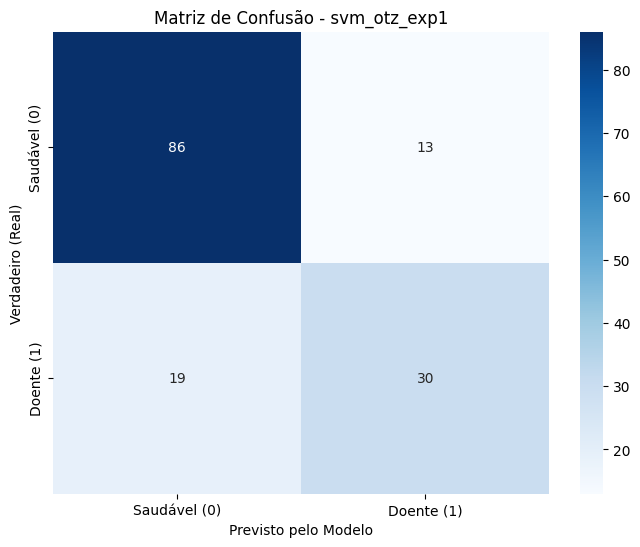

In [33]:
# Avaliar resultados e salvar
y_pred_otz_exp1 = experimento_1.best_model.predict(X_test_exp1)
y_prob_otz_exp1 = experimento_1.best_model.predict_proba(X_test_exp1)[:, 1]

evaluate_model(y_test_exp1, y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1')
save_results(y_pred_otz_exp1, y_prob_otz_exp1, 'svm_otz_exp1', caminho)

## Experimento 2: Conjunto com PCA

In [34]:
X_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_test_pca.csv')
X_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/X_train_pca.csv')
y_test_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_test.csv').squeeze()
y_train_exp2 = pd.read_csv(caminho + 'database/processed/splitted/y_train.csv').squeeze()

### SVM - Default

In [35]:
from sklearn.svm import SVC

svm_exp2 = SVC(kernel='rbf', probability=True, random_state=14)
svm_exp2.fit(X_train_exp2, y_train_exp2)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


=== Métricas svm_def_exp2  ===
    Acurácia: 0.8041
    Precisão: 0.7870
    Recall:   0.7556
    F1-Score: 0.7670
    MCC:      0.5417
    AUC:      0.8549


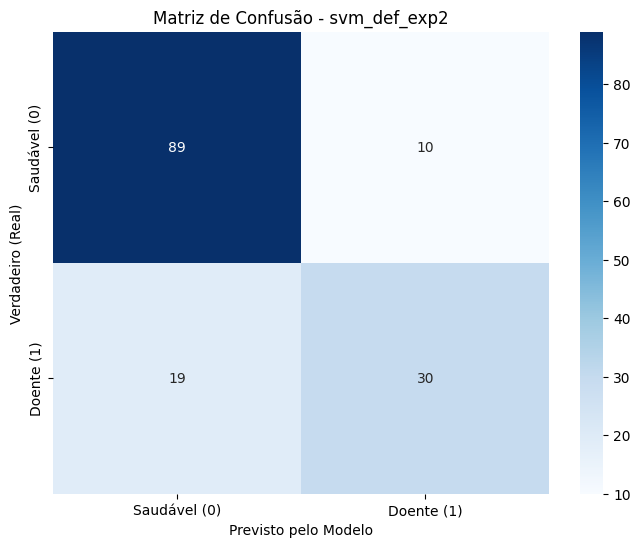

In [36]:
# Avaliar modelo
y_pred_def_exp2 = svm_exp2.predict(X_test_exp2)
y_prob_def_exp2 = svm_exp2.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_def_exp2, y_prob_def_exp2, 'svm_def_exp2')
save_results(y_pred_def_exp2, y_prob_def_exp2, 'svm_def_exp2', caminho)

### SVM - Melhorado

In [37]:
# Criar o experimento
experimento_2 = SVMExperiment(X_train_exp2, y_train_exp2, 'svm_otz_exp2', caminho)
experimento_2.tune_and_fit(n_trials=50)

[I 2026-08-18 19:24:57,956] A new study created in memory with name: no-name-da9f0dc2-6d4e-4d20-8fd2-8780f1427cb0


Iniciando otimização do cenário svm_otz_exp2.


Best trial: 1. Best value: 0.782796:   4%|▍         | 2/50 [00:00<00:03, 12.16it/s]

[I 2026-08-18 19:24:58,037] Trial 0 finished with value: 0.7329384178699246 and parameters: {'kernel': 'sigmoid', 'C': 0.903661587681762, 'gamma': 'scale', 'tol': 0.011651982340001714, 'shrinking': True, 'coef0': 0.5675929673244126}. Best is trial 0 with value: 0.7329384178699246.
[I 2026-08-18 19:24:58,116] Trial 1 finished with value: 0.7827964951252623 and parameters: {'kernel': 'rbf', 'C': 1.5724185463503464, 'gamma': 'auto', 'tol': 0.04364939818045339, 'shrinking': False}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:   4%|▍         | 2/50 [00:00<00:03, 12.16it/s]

[I 2026-08-18 19:24:58,189] Trial 2 finished with value: 0.751203258052573 and parameters: {'kernel': 'poly', 'C': 0.8395201676401916, 'gamma': 'auto', 'tol': 0.009764159787730828, 'shrinking': True, 'degree': 3, 'coef0': 0.9490991617239212}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:   8%|▊         | 4/50 [00:00<00:03, 12.53it/s]

[I 2026-08-18 19:24:58,265] Trial 3 finished with value: 0.6965938541281007 and parameters: {'kernel': 'sigmoid', 'C': 13.420355218734082, 'gamma': 'scale', 'tol': 3.27740745843107e-05, 'shrinking': False, 'coef0': 0.7691725611466463}. Best is trial 1 with value: 0.7827964951252623.
[I 2026-08-18 19:24:58,344] Trial 4 finished with value: 0.7510181414291003 and parameters: {'kernel': 'sigmoid', 'C': 0.211304830880939, 'gamma': 'auto', 'tol': 1.0234158782626789e-05, 'shrinking': True, 'coef0': 0.22570904526897828}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:  12%|█▏        | 6/50 [00:00<00:03, 13.34it/s]

[I 2026-08-18 19:24:58,409] Trial 5 finished with value: 0.7101073676416142 and parameters: {'kernel': 'sigmoid', 'C': 0.13180257162021614, 'gamma': 'auto', 'tol': 5.819931388582941e-05, 'shrinking': True, 'coef0': 0.7180511704005862}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:  16%|█▌        | 8/50 [00:00<00:03, 13.59it/s]

[I 2026-08-18 19:24:58,480] Trial 6 finished with value: 0.7690978649882759 and parameters: {'kernel': 'rbf', 'C': 0.3425475415370615, 'gamma': 'scale', 'tol': 0.08614795476034444, 'shrinking': True}. Best is trial 1 with value: 0.7827964951252623.
[I 2026-08-18 19:24:58,552] Trial 7 finished with value: 0.764655066024929 and parameters: {'kernel': 'sigmoid', 'C': 0.4457227065696099, 'gamma': 'scale', 'tol': 0.0002743488905408422, 'shrinking': False, 'coef0': 0.938991426043695}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:  16%|█▌        | 8/50 [00:00<00:03, 13.59it/s]

[I 2026-08-18 19:24:58,626] Trial 8 finished with value: 0.6242749598913983 and parameters: {'kernel': 'sigmoid', 'C': 60.68171025480182, 'gamma': 'auto', 'tol': 1.1312433646903638e-05, 'shrinking': True, 'coef0': 0.7175709995694969}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 1. Best value: 0.782796:  20%|██        | 10/50 [00:00<00:02, 13.74it/s]

[I 2026-08-18 19:24:58,699] Trial 9 finished with value: 0.7239294088609158 and parameters: {'kernel': 'sigmoid', 'C': 3.232000575899845, 'gamma': 'scale', 'tol': 2.372737039845586e-05, 'shrinking': False, 'coef0': 0.3472028755871136}. Best is trial 1 with value: 0.7827964951252623.
[I 2026-08-18 19:24:58,789] Trial 10 finished with value: 0.7510181414291003 and parameters: {'kernel': 'rbf', 'C': 4.42859049269787, 'gamma': 'auto', 'tol': 0.0023129002680045653, 'shrinking': False}. Best is trial 1 with value: 0.7827964951252623.


Best trial: 11. Best value: 0.805442:  24%|██▍       | 12/50 [00:01<00:03, 12.32it/s]

[I 2026-08-18 19:24:58,888] Trial 11 finished with value: 0.8054424287301 and parameters: {'kernel': 'rbf', 'C': 1.300562061869532, 'gamma': 'scale', 'tol': 0.07233644463208883, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:58,988] Trial 12 finished with value: 0.7782919906207577 and parameters: {'kernel': 'rbf', 'C': 1.5824791911029845, 'gamma': 'auto', 'tol': 0.09767306117314481, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  28%|██▊       | 14/50 [00:01<00:03, 11.43it/s]

[I 2026-08-18 19:24:59,086] Trial 13 finished with value: 0.7647784771072442 and parameters: {'kernel': 'rbf', 'C': 9.478815170147705, 'gamma': 'scale', 'tol': 0.019565096832783884, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,176] Trial 14 finished with value: 0.8008762186844378 and parameters: {'kernel': 'rbf', 'C': 1.7577721266229853, 'gamma': 'scale', 'tol': 0.002020446040842963, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  36%|███▌      | 18/50 [00:01<00:02, 11.30it/s]

[I 2026-08-18 19:24:59,276] Trial 15 finished with value: 0.7373812168332717 and parameters: {'kernel': 'poly', 'C': 10.411864696089538, 'gamma': 'scale', 'tol': 0.0016069219245613575, 'shrinking': False, 'degree': 2, 'coef0': 0.10072459408767498}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,377] Trial 16 finished with value: 0.7240528199432309 and parameters: {'kernel': 'rbf', 'C': 32.894993375692074, 'gamma': 'scale', 'tol': 0.00041515741101026985, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,455] Trial 17 finished with value: 0.7737874861162531 and parameters: {'kernel': 'rbf', 'C': 4.274305295676784, 'gamma': 'scale', 'tol': 0.004209655897639267, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  40%|████      | 20/50 [00:01<00:02, 12.02it/s]

[I 2026-08-18 19:24:59,534] Trial 18 finished with value: 0.8053807231889424 and parameters: {'kernel': 'rbf', 'C': 1.604905319228501, 'gamma': 'scale', 'tol': 0.000503329128159658, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,598] Trial 19 finished with value: 0.6830186350734295 and parameters: {'kernel': 'poly', 'C': 0.7157763670596189, 'gamma': 'scale', 'tol': 0.0003043090212611709, 'shrinking': False, 'degree': 4, 'coef0': 0.0064595589865685255}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,653] Trial 20 finished with value: 0.6741947426878934 and parameters: {'kernel': 'rbf', 'C': 0.10986319827003511, 'gamma': 'scale', 'tol': 0.00016473618939421577, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  48%|████▊     | 24/50 [00:01<00:02, 12.46it/s]

[I 2026-08-18 19:24:59,727] Trial 21 finished with value: 0.8008762186844378 and parameters: {'kernel': 'rbf', 'C': 1.6672415766583417, 'gamma': 'scale', 'tol': 0.0006188974411136797, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,810] Trial 22 finished with value: 0.7963100086387757 and parameters: {'kernel': 'rbf', 'C': 1.959454802922775, 'gamma': 'scale', 'tol': 8.809898868207342e-05, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:24:59,888] Trial 23 finished with value: 0.7739108971985685 and parameters: {'kernel': 'rbf', 'C': 5.5062148745459965, 'gamma': 'scale', 'tol': 0.001007127267926818, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  52%|█████▏    | 26/50 [00:02<00:02, 11.49it/s]

[I 2026-08-18 19:25:00,005] Trial 24 finished with value: 0.7601505615204246 and parameters: {'kernel': 'rbf', 'C': 0.4751660065718691, 'gamma': 'scale', 'tol': 0.003698856809351193, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,099] Trial 25 finished with value: 0.7918672096754289 and parameters: {'kernel': 'rbf', 'C': 2.8011298964890448, 'gamma': 'scale', 'tol': 0.03337300631623129, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,194] Trial 26 finished with value: 0.7600888559792668 and parameters: {'kernel': 'poly', 'C': 1.0319255351119003, 'gamma': 'scale', 'tol': 0.006805657372765491, 'shrinking': False, 'degree': 4, 'coef0': 0.5142157756194996}. Best is trial 11 with value: 0.8054424287301.


[I 2026-08-18 19:25:00,290] Trial 27 finished with value: 0.7377514500802173 and parameters: {'kernel': 'rbf', 'C': 20.99947552991262, 'gamma': 'scale', 'tol': 0.0011136066485649887, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,388] Trial 28 finished with value: 0.7693446871529064 and parameters: {'kernel': 'rbf', 'C': 6.965438777066443, 'gamma': 'scale', 'tol': 0.00017407995619553673, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  64%|██████▍   | 32/50 [00:02<00:01, 11.17it/s]

[I 2026-08-18 19:25:00,474] Trial 29 finished with value: 0.7782919906207577 and parameters: {'kernel': 'rbf', 'C': 1.0019749018514645, 'gamma': 'scale', 'tol': 0.013308061422201332, 'shrinking': True}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,579] Trial 30 finished with value: 0.7735406639516228 and parameters: {'kernel': 'poly', 'C': 2.613871626380165, 'gamma': 'scale', 'tol': 0.0033210447458486758, 'shrinking': False, 'degree': 2, 'coef0': 0.3200056037244119}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,658] Trial 31 finished with value: 0.8053807231889424 and parameters: {'kernel': 'rbf', 'C': 1.6064120723689927, 'gamma': 'scale', 'tol': 0.0005318900027456391, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  68%|██████▊   | 34/50 [00:02<00:01, 11.61it/s]

[I 2026-08-18 19:25:00,742] Trial 32 finished with value: 0.7646550660249289 and parameters: {'kernel': 'rbf', 'C': 0.6017209970694304, 'gamma': 'scale', 'tol': 0.0006393982671155832, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,808] Trial 33 finished with value: 0.8009379242255955 and parameters: {'kernel': 'rbf', 'C': 1.1904752008236652, 'gamma': 'scale', 'tol': 0.0001248028948234789, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:00,884] Trial 34 finished with value: 0.8008762186844378 and parameters: {'kernel': 'rbf', 'C': 1.356018241913934, 'gamma': 'scale', 'tol': 0.00011542712442272542, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  72%|███████▏  | 36/50 [00:03<00:01, 11.64it/s]

[I 2026-08-18 19:25:00,979] Trial 35 finished with value: 0.773664075033938 and parameters: {'kernel': 'rbf', 'C': 0.26866655319465643, 'gamma': 'scale', 'tol': 4.1627412944770724e-05, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,088] Trial 36 finished with value: 0.7781685795384425 and parameters: {'kernel': 'rbf', 'C': 1.0757790901833555, 'gamma': 'auto', 'tol': 0.0005961767453033283, 'shrinking': True}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  80%|████████  | 40/50 [00:03<00:00, 10.95it/s]

[I 2026-08-18 19:25:01,193] Trial 37 finished with value: 0.7601505615204246 and parameters: {'kernel': 'rbf', 'C': 0.7116132217467712, 'gamma': 'scale', 'tol': 0.00021727603481676194, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,286] Trial 38 finished with value: 0.751203258052573 and parameters: {'kernel': 'poly', 'C': 2.4433424331089864, 'gamma': 'scale', 'tol': 8.238368402691142e-05, 'shrinking': True, 'degree': 3, 'coef0': 0.4123249021006677}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,376] Trial 39 finished with value: 0.7601505615204246 and parameters: {'kernel': 'sigmoid', 'C': 0.16153883480200018, 'gamma': 'auto', 'tol': 0.00038669287401516347, 'shrinking': False, 'coef0': 0.16828162600120605}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  84%|████████▍ | 42/50 [00:03<00:00, 10.59it/s]

[I 2026-08-18 19:25:01,484] Trial 40 finished with value: 0.760088855979267 and parameters: {'kernel': 'rbf', 'C': 0.4116179341529753, 'gamma': 'scale', 'tol': 0.04863708162820663, 'shrinking': True}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,575] Trial 41 finished with value: 0.8008762186844378 and parameters: {'kernel': 'rbf', 'C': 1.3979922776870908, 'gamma': 'scale', 'tol': 0.001512172365492016, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  88%|████████▊ | 44/50 [00:03<00:00, 10.82it/s]

[I 2026-08-18 19:25:01,669] Trial 42 finished with value: 0.7963717141799335 and parameters: {'kernel': 'rbf', 'C': 2.196893391440153, 'gamma': 'scale', 'tol': 2.3609849784603288e-05, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,750] Trial 43 finished with value: 0.7783536961619153 and parameters: {'kernel': 'rbf', 'C': 3.252306421182474, 'gamma': 'scale', 'tol': 0.0004778004005282546, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,827] Trial 44 finished with value: 0.7149821053930644 and parameters: {'kernel': 'sigmoid', 'C': 1.1802397966586853, 'gamma': 'scale', 'tol': 0.006388182057610929, 'shrinking': False, 'coef0': 0.6111401766974978}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  92%|█████████▏| 46/50 [00:04<00:00, 11.29it/s]

[I 2026-08-18 19:25:01,905] Trial 45 finished with value: 0.7600271504381094 and parameters: {'kernel': 'rbf', 'C': 3.951907661101504, 'gamma': 'auto', 'tol': 0.00011666368754552793, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:01,995] Trial 46 finished with value: 0.7646550660249289 and parameters: {'kernel': 'rbf', 'C': 0.8466632700685984, 'gamma': 'scale', 'tol': 0.001554773594781889, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442:  96%|█████████▌| 48/50 [00:04<00:00, 11.02it/s]

[I 2026-08-18 19:25:02,092] Trial 47 finished with value: 0.7691595705294335 and parameters: {'kernel': 'rbf', 'C': 0.5357088533350242, 'gamma': 'scale', 'tol': 5.287253087923641e-05, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
[I 2026-08-18 19:25:02,195] Trial 48 finished with value: 0.6606812291743799 and parameters: {'kernel': 'sigmoid', 'C': 1.9361531063664652, 'gamma': 'auto', 'tol': 0.0627796978675758, 'shrinking': True, 'coef0': 0.8344150119964409}. Best is trial 11 with value: 0.8054424287301.


Best trial: 11. Best value: 0.805442: 100%|██████████| 50/50 [00:04<00:00, 11.54it/s]

[I 2026-08-18 19:25:02,281] Trial 49 finished with value: 0.7739108971985685 and parameters: {'kernel': 'rbf', 'C': 5.830071752695254, 'gamma': 'scale', 'tol': 0.026718786236616398, 'shrinking': False}. Best is trial 11 with value: 0.8054424287301.
Melhor pontuação (CV): 0.8054
Melhores parâmetros:
{'kernel': 'rbf', 'C': 1.300562061869532, 'gamma': 'scale', 'tol': 0.07233644463208883, 'shrinking': False}


In [38]:
import optuna
fig = optuna.visualization.plot_param_importances(experimento_2.study)
fig.show()

fig = optuna.visualization.plot_optimization_history(experimento_2.study)
fig.show()

=== Métricas svm_otz_exp2  ===
    Acurácia: 0.8108
    Precisão: 0.7975
    Recall:   0.7607
    F1-Score: 0.7736
    MCC:      0.5569
    AUC:      0.8586


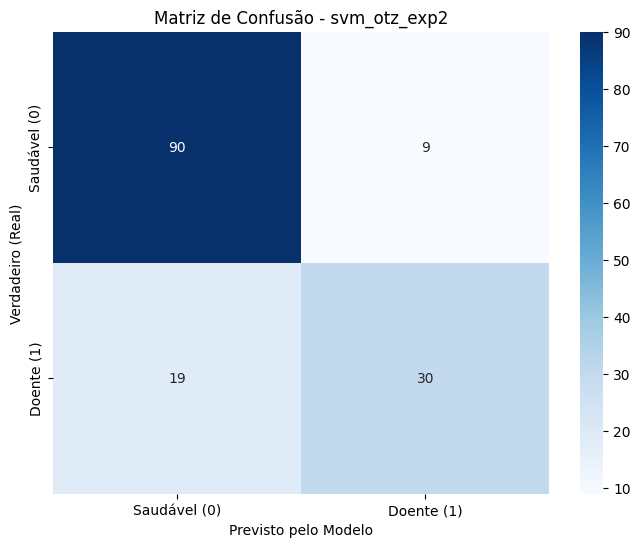

In [39]:
# Avaliar resultados e salvar
y_pred_otz_exp2 = experimento_2.best_model.predict(X_test_exp2)
y_prob_otz_exp2 = experimento_2.best_model.predict_proba(X_test_exp2)[:, 1]

evaluate_model(y_test_exp2, y_pred_otz_exp2, y_prob_otz_exp2, 'svm_otz_exp2')
save_results(y_pred_otz_exp2, y_prob_otz_exp2, 'svm_otz_exp2', caminho)